#BERT-Base

###Data Preprocessing

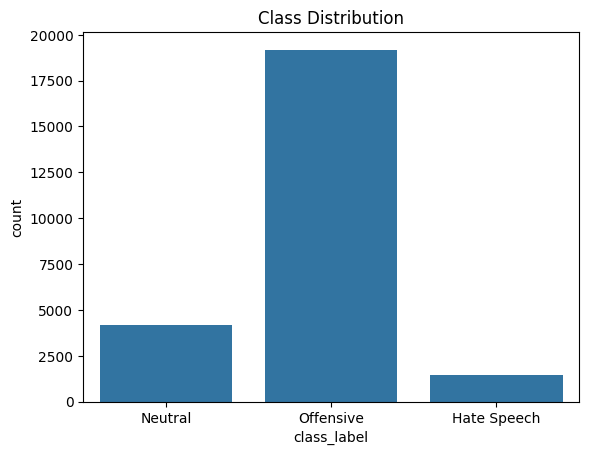

,tweet,class,class_label
0,!!! RT @mayasolovely: As a woman you shouldn't...,2,Neutral
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,1,Offensive
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,1,Offensive
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,1,Offensive
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,1,Offensive


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("https://raw.githubusercontent.com/t-davidson/hate-speech-and-offensive-language/master/data/labeled_data.csv")
df['class_label'] = df['class'].map({0:'Hate Speech', 1:'Offensive', 2:'Neutral'})
df = df[['tweet', 'class', 'class_label']]

sns.countplot(data=df, x='class_label')
plt.title('Class Distribution')
plt.show()
df.head()


Train label distribution:
 label
0     1144
1     3330
2    15352
Name: count, dtype: int64

Test label distribution:
 label
0     286
1     833
2    3838
Name: count, dtype: int64


/tmp/ipython-input-4059855047.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=train_label_counts.index, y=train_label_counts.values, palette="Blues_d")
/tmp/ipython-input-4059855047.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=test_label_counts.index, y=test_label_counts.values, palette="Greens_d")


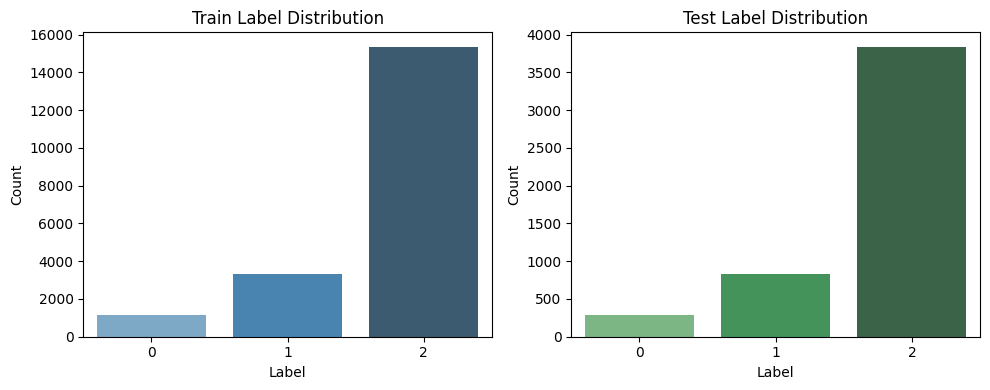

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from datasets import Dataset
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Label encoding
le = LabelEncoder()
df['label'] = le.fit_transform(df['class_label'])

# Split data
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df['tweet'], df['label'], test_size=0.2, stratify=df['label'], random_state=42
)

# Convert to Hugging Face Dataset
train_ds = Dataset.from_dict({'text': train_texts.tolist(), 'label': train_labels.tolist()})
test_ds = Dataset.from_dict({'text': test_texts.tolist(), 'label': test_labels.tolist()})
train_label_counts = pd.Series(train_labels).value_counts().sort_index()
test_label_counts = pd.Series(test_labels).value_counts().sort_index()
print("Train label distribution:\n", train_label_counts)
print("\nTest label distribution:\n", test_label_counts)

# Visualize
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.barplot(x=train_label_counts.index, y=train_label_counts.values, palette="Blues_d")
plt.title("Train Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
sns.barplot(x=test_label_counts.index, y=test_label_counts.values, palette="Greens_d")
plt.title("Test Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")

plt.tight_layout()
plt.show()


In [6]:
!pip -q install -U "transformers>=4.35.2" "datasets>=2.18.0" "accelerate>=0.25.0" "evaluate" "scikit-learn"
import transformers, datasets, accelerate, torch
print("Transformers:", transformers.__version__)
print("Datasets:", datasets.__version__)
print("Accelerate:", accelerate.__version__)
print("CUDA:", torch.cuda.is_available())


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 103.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 64.4 MB/s eta 0:00:00
Transformers: 4.56.0
Datasets: 4.0.0
Accelerate: 1.10.1
CUDA: True


### BERT training

In [11]:
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, f1_score
import torch

train_ds = Dataset.from_dict({'text': list(train_texts), 'label': list(train_labels)})
test_ds  = Dataset.from_dict({'text': list(test_texts),  'label': list(test_labels)})
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
def tokenize_function(example):
    return tokenizer(example["text"], padding="max_length", truncation=True)

train_ds = train_ds.map(tokenize_function, batched=True)
test_ds  = test_ds.map(tokenize_function,  batched=True)

train_ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])
test_ds.set_format("torch",  columns=["input_ids", "attention_mask", "label"])

model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=3)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro")
    }

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=2,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    weight_decay=0.01,
    logging_steps=100,
    save_strategy="no",
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics
)

trainer.train()
metrics = trainer.evaluate(test_ds)
print(metrics)


Map:   0%|          | 0/19826 [00:00<?, ? examples/s]

Map:   0%|          | 0/4957 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Step,Training Loss
100,0.505100
200,0.470100
300,0.398800
400,0.323000
500,0.301200
600,0.337400
700,0.319900
800,0.400000
900,0.383200
1000,0.362400


{'eval_loss': 0.28612321615219116, 'eval_accuracy': 0.9158765382287674, 'eval_f1_macro': 0.7466778356965461, 'eval_runtime': 135.9581, 'eval_samples_per_second': 36.46, 'eval_steps_per_second': 2.28, 'epoch': 2.0}


### BERT evaluation

Metrics: {'eval_loss': 0.28612321615219116, 'eval_accuracy': 0.9158765382287674, 'eval_f1_macro': 0.7466778356965461, 'eval_runtime': 136.4951, 'eval_samples_per_second': 36.316, 'eval_steps_per_second': 2.271, 'epoch': 2.0}

Classification Report:

                    precision    recall  f1-score   support

       hate speech     0.5361    0.3112    0.3938       286
offensive language     0.8851    0.9064    0.8956       833
           neutral     0.9385    0.9630    0.9506      3838

          accuracy                         0.9159      4957
         macro avg     0.7866    0.7269    0.7467      4957
      weighted avg     0.9064    0.9159    0.9092      4957



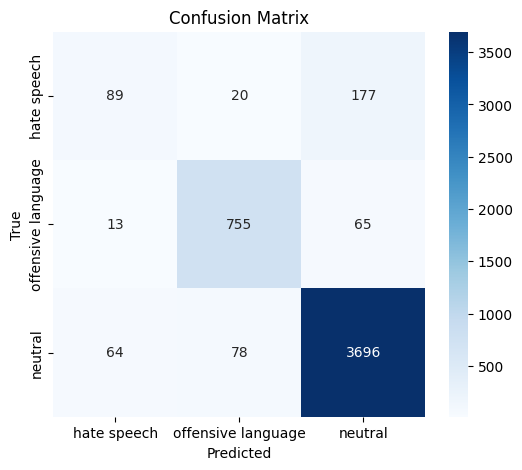

In [13]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

metrics = trainer.evaluate(test_ds)
print("Metrics:", metrics)
preds_output = trainer.predict(test_ds)
y_true = preds_output.label_ids
y_pred = preds_output.predictions.argmax(-1)

target_names = ["hate speech", "offensive language", "neutral"]
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=target_names, digits=4))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_names,
            yticklabels=target_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()
